<a href="https://colab.research.google.com/github/Arczisork/Sztuczna-inteligencja/blob/main/sztuczna_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)



2.19.0


In [24]:
observations = 1000
xs = np.random.uniform(low=-10,high=10,size=(observations,1))
zs = np.random.uniform(low=-10,high=10,size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)


(1000, 2)


In [25]:
noise = np.random.uniform(low=-1,high=1,size=(observations,1))
targets = 2*xs - 3*xs + 5 + noise
np.savez('TF_dataset',inputs=inputs,targets=targets)
print(targets.shape)


(1000, 1)


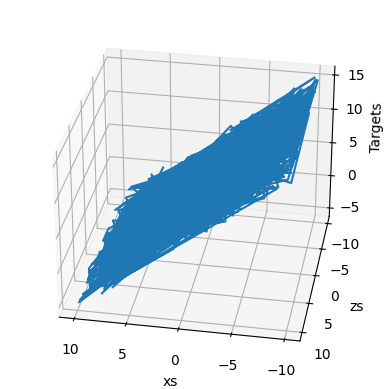

In [26]:

targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [27]:
init_range= 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range,size=1)
print(weights,biases)


[[-0.03390668]
 [ 0.02631384]] [0.05373125]


In [28]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range (100):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas **2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T,deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)


30.606496644014083
13.655561054261868
11.572893482136713
10.960128951366997
10.51654566726736
10.106697179315407
9.714931923319403
9.338836030192386
8.977579083981386
8.63054899840227
8.297181926221244
7.976939449578571
7.669304788407615
7.373781568804399
7.089892967324931
6.817180934029677
6.555205452366412
6.303543829062193
6.061790012093726
5.829553935525988
5.606460890146629
5.392150918878579
5.186278235995017
4.988510669199612
4.798529123671806
4.616027067212403
4.440710035658744
4.2722951577714685
4.110510698826282
3.9550956221742855
3.805799168063515
3.662380449042069
3.524608061290037
3.3922597112531223
3.2651218569755303
3.1429893635534234
3.025665172153018
2.9129599820592946
2.804691945242309
2.7006863729482866
2.600775453842104
2.504797983246368
2.412599103040237
2.3240300517983083
2.238947924766425
2.157215443287132
2.078700733302747
2.0032771125786657
1.930822886303596
1.8612211507369187
1.7943596045863583
1.7301303678116389
1.6684298075617565
1.6091583709650223
1.55222042

In [31]:
print(weights, biases)

[[-1.01090692]
 [-0.00544508]] [4.34819073]


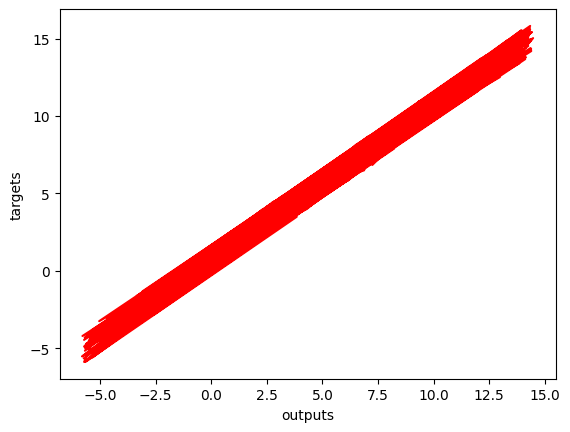

In [32]:
plt.plot(outputs, targets, color='red')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()